### Quantile Regression Theory

Quantile Regression is a robust regression technique that estimates the conditional quantiles of the response variable rather than the mean. It is particularly useful for understanding the distribution of outcomes across different levels and is more resistant to outliers than ordinary least squares regression.

#### Objective Function
The Quantile Regression estimator for the $ \tau $-th quantile (where $ 0 < \tau < 1 $) minimizes the following weighted sum of absolute deviations:

$$
\min_{\beta} \sum_{i=1}^{n} \rho_{\tau}(y_i - X_i \beta)
$$

where the check function (or quantile loss) is defined as:

$$
\rho_{\tau}(u) = u(\tau - \mathbb{1}_{u < 0}) = \begin{cases} \tau |u| & \text{if } u \geq 0 \\ (1 - \tau)|u| & \text{if } u < 0 \end{cases}
$$

This can be rewritten in matrix form as:

$$
\min_{\beta} \sum_{i=1}^{n} \rho_{\tau}(y_i - X_i \beta)
$$

#### Connection to LAD (Least Absolute Deviations)
Least Absolute Deviations (LAD) regression is a special case of Quantile Regression where $ \tau = 0.5 $ (the median):

$$
\min_{\beta} \sum_{i=1}^{n} |y_i - X_i \beta|
$$

LAD provides a robust alternative to OLS by minimizing absolute errors rather than squared errors, making it less sensitive to outliers.

#### Key Properties
- **Robustness**: Less sensitive to outliers and heavy-tailed distributions compared to mean-based methods.
- **Full Distribution Information**: Provides insights into different points of the conditional distribution, not just the mean.
- **Asymmetric Loss**: Different $ \tau $ values allow modeling of upper and lower tails separately.
- **No Closed-Form Solution**: Typically solved using linear programming or iterative algorithms (e.g., simplex method).

#### Assumptions and Limitations
- Does not assume normality of errors.
- Computationally more intensive than OLS, especially for large datasets.
- Interpretation requires careful consideration of the specific quantile level.
- Standard errors require special estimation techniques (e.g., bootstrap).

tau = 1.00%
Intercept     37.180942
weight        -6.018054
horsepower    -0.008726
dtype: float64

tau = 5.00%
Intercept     35.174205
weight        -5.041781
horsepower    -0.012848
dtype: float64

tau = 25.00%
Intercept     33.909752
weight        -3.810973
horsepower    -0.024390
dtype: float64

tau = 50.00%
Intercept     36.626012
weight        -3.605697
horsepower    -0.035591
dtype: float64

tau = 75.00%
Intercept     38.439139
weight        -4.148390
horsepower    -0.025759
dtype: float64

tau = 95.00%
Intercept     42.875987
weight        -3.122802
horsepower    -0.049933
dtype: float64

tau = 99.00%
Intercept     42.875995
weight        -3.122803
horsepower    -0.049933
dtype: float64



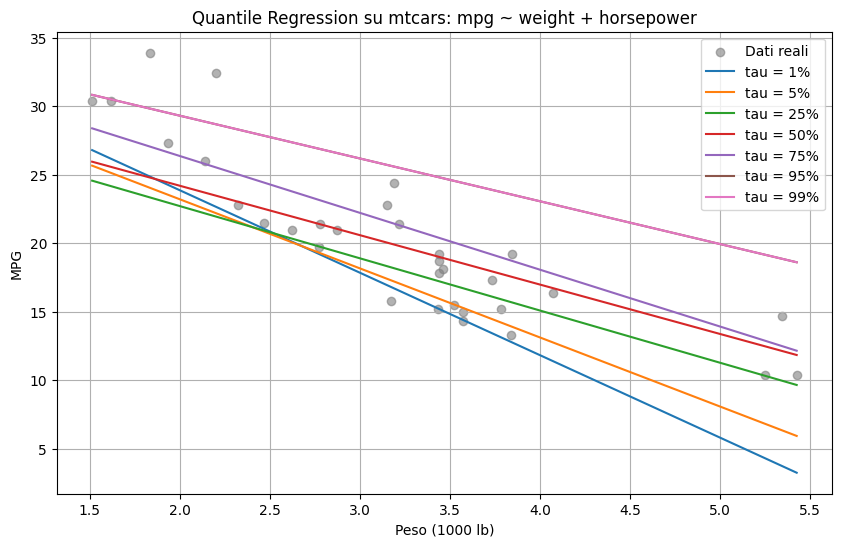

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Carica un dataset reale: mtcars
data = sm.datasets.get_rdataset("mtcars").data
data = data.rename(columns={'mpg': 'mpg', 'wt': 'weight', 'hp': 'horsepower'})

taus = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
results = {}

# Stima la regressione quantile per ogni tau
for tau in taus:
    model = smf.quantreg("mpg ~ weight + horsepower", data)
    res = model.fit(q=tau)
    results[tau] = res
    print(f"tau = {tau:.2%}")
    print(res.params)
    print()

# Prepara una griglia per il grafico
weight_grid = np.linspace(data["weight"].min(), data["weight"].max(), 100)
hp_mean = data["horsepower"].mean()
pred_df = pd.DataFrame({"weight": weight_grid, "horsepower": hp_mean})

plt.figure(figsize=(10, 6))
plt.scatter(data["weight"], data["mpg"], color="gray", alpha=0.6, label="Dati reali")

for tau, res in results.items():
    y_pred = res.predict(pred_df)
    plt.plot(weight_grid, y_pred, label=f"tau = {int(tau*100)}%")

plt.xlabel("Peso (1000 lb)")
plt.ylabel("MPG")
plt.title("Quantile Regression su mtcars: mpg ~ weight + horsepower")
plt.legend()
plt.grid(True)
plt.show()

## Ordinary Least Squares (OLS) vs Least Absolute Deviations (LAD) — Technical Note
This note compares OLS and LAD regression methods, their objectives, statistical properties, computational aspects, and practical guidance for choice and inference.

## Problem setup
Given data (y, X) with y ∈ R^n and X ∈ R^{n×p}, both methods estimate β ∈ R^p in the linear model
$$
y = X\beta + \varepsilon.
$$

## Estimation objectives
- OLS: minimize the sum of squared residuals
  $$
  \hat\beta_{OLS} = \arg\min_\beta \sum_{i=1}^n (y_i - x_i^\top\beta)^2.
  $$
  Normal equations: $X^\top (y - X\hat\beta_{OLS}) = 0$; closed-form solution when $X^\top X$ invertible:
  $$
  \hat\beta_{OLS} = (X^\top X)^{-1} X^\top y.
  $$

- LAD (a.k.a. L1 or median regression): minimize the sum of absolute residuals
  $$
  \hat\beta_{LAD} = \arg\min_\beta \sum_{i=1}^n |y_i - x_i^\top\beta|.
  $$
  No simple closed-form; optimality requires
  $$
  \sum_{i=1}^n x_i \, \text{sign}(y_i - x_i^\top\hat\beta_{LAD}) = 0
  $$
  where sign(·) handles subgradient at zero. LAD can be cast as a linear program.

## Statistical properties

- Bias and consistency
  - Both estimators are consistent under standard conditions (identifiability, exogeneity).
  - OLS unbiased under E[ε|X]=0 in finite samples (given linearity and full-rank X). LAD is generally biased in small samples but consistent under mild conditions.

- Efficiency
  - OLS is the Best Linear Unbiased Estimator (BLUE) under Gauss–Markov assumptions (homoskedastic errors, zero mean, finite variance) and is asymptotically efficient if errors are Gaussian.
  - LAD is asymptotically efficient under heavy-tailed distributions or when the error distribution has higher kurtosis; LAD is optimal for estimating conditional medians (i.e., minimizes expected absolute loss).

- Asymptotic distributions
  - OLS: under regularity and homoskedasticity,
    $$
    \sqrt{n}(\hat\beta_{OLS}-\beta) \xrightarrow{d} N(0,\ \sigma^2 Q^{-1}),
    $$
    where $Q = \lim_{n\to\infty}\frac{1}{n}X^\top X$ and $\sigma^2 = \mathrm{Var}(\varepsilon)$.
  - LAD: under smoothness of error density f at zero and regularity,
    $$
    \sqrt{n}(\hat\beta_{LAD}-\beta) \xrightarrow{d} N\big(0,\ \tfrac{1}{4 f(0)^2} Q^{-1}\big),
    $$
    where f(0) is the error density at zero. Hence LAD variance depends on f(0) (density mass at zero).

- Influence and robustness
  - OLS: influence function grows with the residual; sensitive to outliers in y (squared residuals amplify large errors). Leverage (large x) increases influence.
  - LAD: influence of a single large residual is bounded by the sign function (robust to large y-outliers); still sensitive to high-leverage x values. Overall, LAD has higher robustness to vertical outliers.

## Inference and standard errors
- OLS: analytical variance estimator available:
  $$
  \widehat{\mathrm{Var}}(\hat\beta_{OLS}) = \hat\sigma^2 (X^\top X)^{-1}
  $$
  with $\hat\sigma^2 = \frac{1}{n-p}\sum \hat\varepsilon_i^2$. Robust (heteroskedastic-consistent) estimators (e.g., HC0–HC3) are standard.

- LAD: asymptotic variance involves f(0), so standard errors require estimating f(0) or using resampling:
  - Estimate density f at residual 0 via kernel methods and plug into the asymptotic variance formula.
  - Alternatively, use bootstrap (percentile or studentized) or inversion of quantile regression covariance estimators. Many software implementations provide robust standard errors for quantile regression (LAD is quantile q=0.5).

## Computational aspects
- OLS: very fast; closed form or via QR decomposition for numerical stability. Complexity O(np^2) or less with optimized BLAS/LAPACK.
- LAD: solved via linear programming or interior-point / simplex methods; can be formulated as quantile regression with q=0.5 and solved by linear programming or specialized algorithms (e.g., Barrodale–Roberts). Typically slower than OLS, but practical for moderate n,p.


In [ ]:
ols_res = smf.ols("mpg ~ weight + horsepower", data).fit()
lad_res = smf.quantreg("mpg ~ weight + horsepower", data).fit(q=0.5)

pred_df = pd.DataFrame({"weight": weight_grid, "horsepower": hp_mean})
y_ols = ols_res.predict(pred_df)
y_lad = lad_res.predict(pred_df)

ols_resid = ols_res.resid
outliers_idx = np.argsort(np.abs(ols_resid))[-4:]
outliers = data.iloc[outliers_idx]

plt.figure(figsize=(10, 6))
plt.scatter(data["weight"], data["mpg"], color="gray", alpha=0.6, label="Dati reali")
plt.scatter(outliers["weight"], outliers["mpg"], facecolors="none", edgecolors="red", s=120, label="Outlier OLS")

plt.plot(weight_grid, y_ols, color="blue", label="OLS")
plt.plot(weight_grid, y_lad, color="orange", linestyle="--", label="LAD (mediana)")

for idx, row in outliers.iterrows():
    plt.annotate(idx, (row.weight, row.mpg), xytext=(5, -8), textcoords="offset points", fontsize=8)

plt.xlabel("Peso (1000 lb)")
plt.ylabel("MPG")
plt.title("Confronto OLS vs LAD su mtcars (outlier evidenziati)")
plt.legend()
plt.grid(True)
plt.show()